# **XGBOOST + SHAP NOTEBOOK**

### Importing Libraries

In [24]:
import pandas as pd
import numpy as np

import xgboost as xgb
import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

### Load Dataset

In [25]:
df = pd.read_csv('../data/processed/engineered_churn.csv')
display(df.head())
X = df.drop('Churn', axis=1) 
y = df['Churn']

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,totalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,high_value_customer,tenure_group_Long-Term,tenure_group_Loyal,tenure_group_New
0,0,1,29.85,29.85,0,29.85,0,1,0,0,...,0,0,1,0,1,0,0,False,False,True
1,0,34,56.95,1889.50,0,1889.50,1,0,0,1,...,1,0,0,0,0,1,0,False,True,False
2,0,2,53.85,108.15,1,108.15,1,0,0,1,...,0,0,1,0,0,1,0,False,False,True
3,0,45,42.30,1840.75,0,1840.75,1,0,0,0,...,1,0,0,0,0,0,0,False,True,False
4,0,2,70.70,151.65,1,151.65,0,0,0,1,...,0,0,1,0,1,0,1,False,False,True


### Remove Null Values

In [27]:
df.dropna(inplace=True)

### Verify Target Column

In [28]:
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


### Remove object column

In [29]:
object_cols = df.select_dtypes(include='object').columns

print("Object Columns:")
print(object_cols)

Object Columns:
Index([], dtype='object')


### Convert boolean Columns

In [30]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

### Force Numberic dtypes

In [32]:
df = df.astype(float)

### Verify Datatypes

In [33]:
print(df.dtypes.unique())

[dtype('float64')]


### Feature & target

In [35]:
X = df.drop('Churn', axis=1)
y = df['Churn']

### Train test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Successful")

Train-Test Split Successful


### XGBoost Model

In [37]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

### Train Model

In [38]:
xgb_model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


### Predictions

In [39]:
predictions = xgb_model.predict(X_test)

### Model Evalution

In [40]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        predictions
    )
)

print("\nAccuracy Score:\n")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print("\nROC-AUC Score:\n")

print(
    roc_auc_score(
        y_test,
        predictions
    )
)


Classification Report:

              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1033
         1.0       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407


Confusion Matrix:

[[905 128]
 [178 196]]

Accuracy Score:

0.7825159914712153

ROC-AUC Score:

0.7000766160552049


### Feature Importance

In [41]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 15 Important Features:\n")

print(
    importance.head(15)
)


Top 15 Important Features:

                               Feature  Importance
34                    tenure_group_New    0.198994
11         InternetService_Fiber optic    0.161870
26                   Contract_Two year    0.138158
31                 high_value_customer    0.064059
25                   Contract_One year    0.056983
12                  InternetService_No    0.048380
13  OnlineSecurity_No internet service    0.039581
15    OnlineBackup_No internet service    0.036125
1                               tenure    0.023935
29      PaymentMethod_Electronic check    0.020678
24                 StreamingMovies_Yes    0.016192
14                  OnlineSecurity_Yes    0.015084
8                     PhoneService_Yes    0.013482
22                     StreamingTV_Yes    0.013348
10                   MultipleLines_Yes    0.012293


### Feature Importance Plot

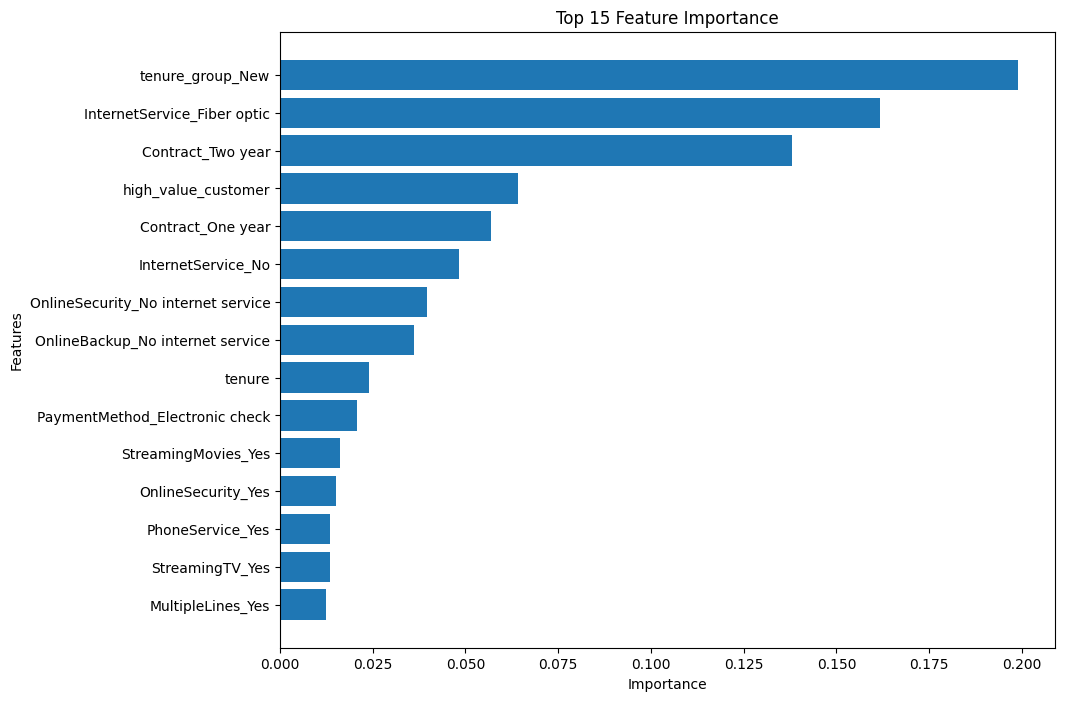

In [42]:
plt.figure(figsize=(10,8))
plt.barh(
    importance['Feature'].head(15),
    importance['Importance'].head(15)
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

###  SHAP EXPLAINABILITY

In [43]:
print("\nGenerating SHAP Explainer...\n")

explainer = shap.Explainer(
    xgb_model,
    X_train
)


Generating SHAP Explainer...



### Generate SHAP Values

In [44]:
shap_values = explainer(
    X_test
)

print("SHAP Values Generated Successfully")

 99%|===================| 1391/1407 [00:29<00:00]        

SHAP Values Generated Successfully


### SHAP Summary Plot

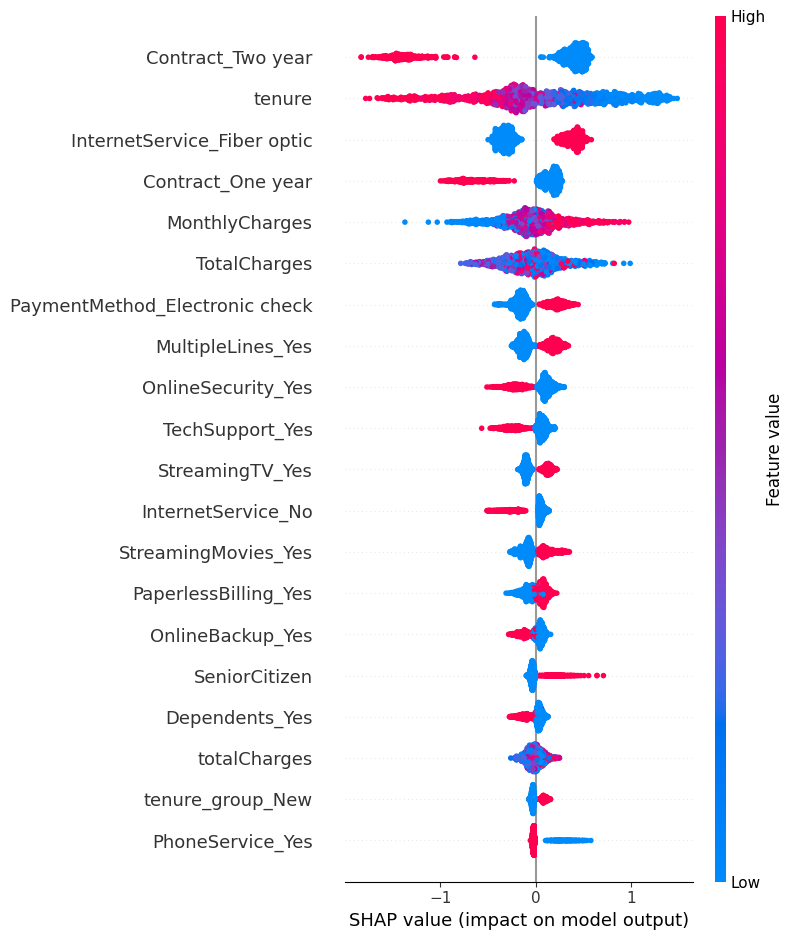

In [45]:
shap.summary_plot(
    shap_values,
    X_test
)

### SHAP Bar Plot

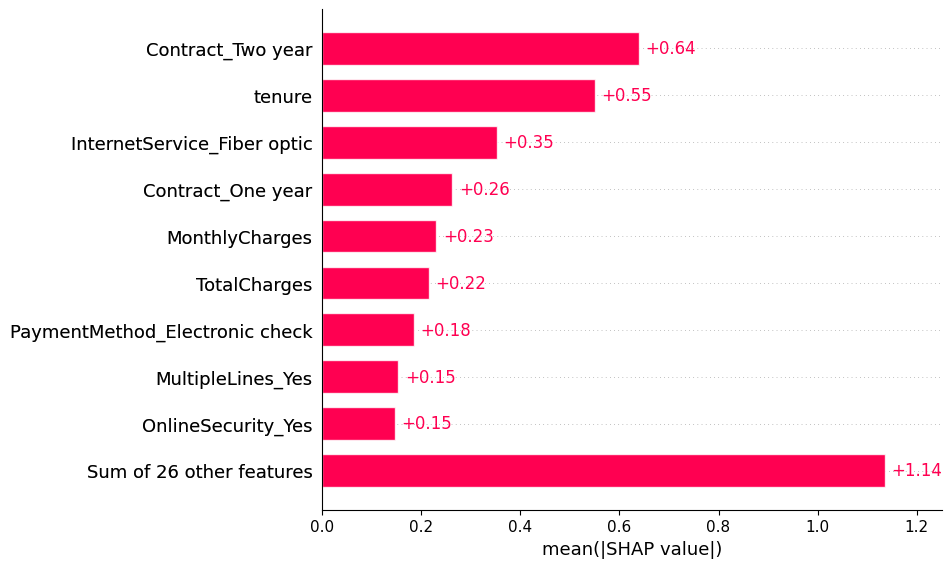

In [46]:
shap.plots.bar(
    shap_values
)

### SHAP Waterfall Plot

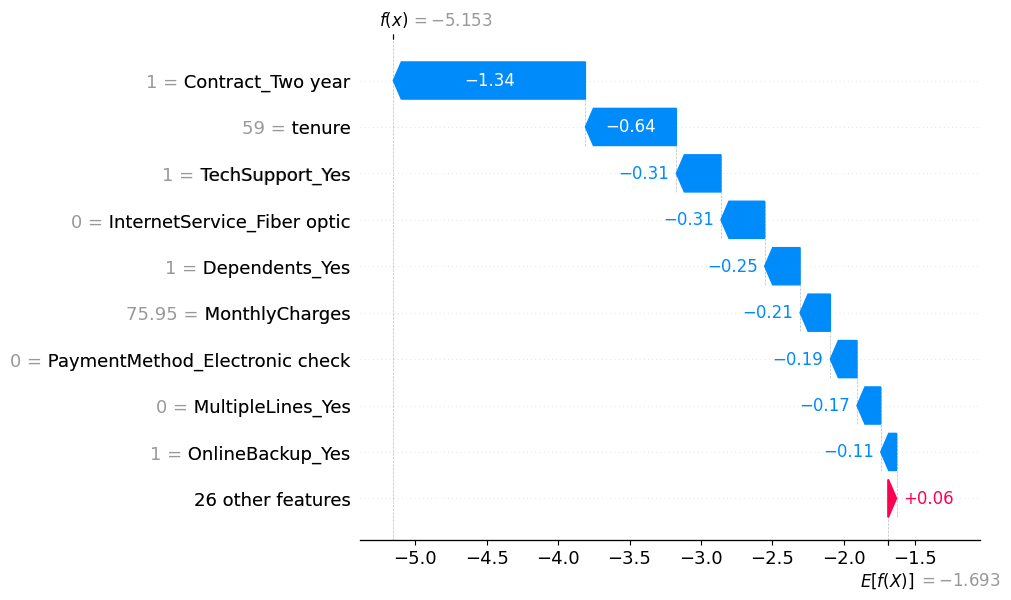

In [47]:
shap.plots.waterfall(
    shap_values[0]
)